In [1]:
import numpy as np
import input_parameters as parmt
import matplotlib.pyplot as plt
import matplotlib.colors
from epsilon_routines import epsilon_r
from binning import gen_bin_centers

#%matplotlib inline

mElectron = 5.1099894e5
alpha = 1.0/137.03599908

q = np.arange(0.01, 1, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

In [2]:
#RPA
binned_eps = np.load('test_resources/epsilon_1q_50E_tz_6/binned_eps.npy')
bin_centers = gen_bin_centers(q_max=1)
eps = epsilon_r(bin_centers, binned_eps)

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:133: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


In [3]:
#DarkELF
import sys
import os
sys.path.append(os.getcwd()+'/../DarkELF')
from darkelf import darkelf, targets

darkelf_gpaw = darkelf(target='Si', filename='Si_gpaw_noLFE.dat')

 .... Loading files for Si
Loaded Si_gpaw_noLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, “Intensity of diffracted intensities,” in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554–595, https://onlinelibrary.wiley.com/doi/pdf/10.1107/97809553602060000
Loaded /home/meganhott/Research/dielectric_pyscf/../DarkELF/darkelf/../data/Si/Si_pDoS.dat for partial densi

In [4]:
#Lindhard model
VCell = 5.209e-9
nValence = 8
MCell = 52322355000.0
mElectron = 5.1099894e5
alpha = 1.0/137.03599908

def Lindhard(om, q, fp): #energy, q, 
    q = q*alpha*mElectron #convert q from ame to eV
    def plog(x):
        return np.log(np.abs(x)) + 1j*np.angle(x)
    ne = nValence/VCell
    kF = (3*np.pi**2*ne)**(1./3.)
    omp = np.sqrt(4*np.pi*alpha*ne/mElectron)
    vF = kF/mElectron
    Gp = fp*omp
    Qp = q/(2*kF) + (om + 1j*Gp)/(q*vF)
    Qm = q/(2*kF) - (om + 1j*Gp)/(q*vF)
    factor1 = 3*(omp**2)/(q**2)/(vF**2)
    factor2 = 0.5 + kF/(4*q)*(1-Qm**2)*plog((Qm+1)/(Qm-1)) + kF/(4*q)*(1-Qp**2)*plog((Qp+1)/(Qp-1))
    return 1 + factor1*factor2

E_mesh, q_mesh = np.meshgrid(E, q)
eps_l = Lindhard(E_mesh, q_mesh, 0.1)

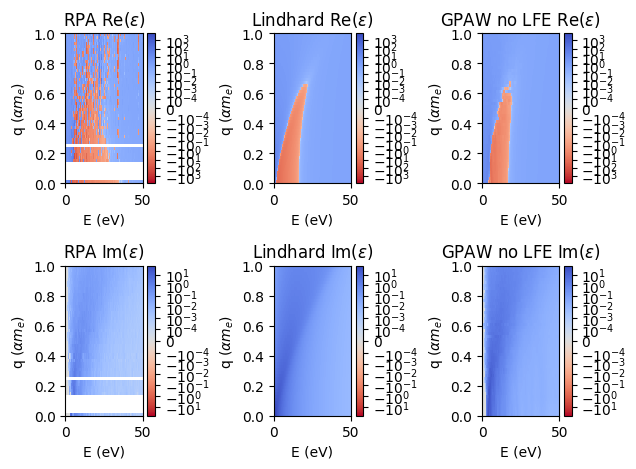

In [27]:
#Full Re and Im Plots
c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.concatenate([np.real(eps[np.invert(np.isnan(eps))]), np.real(eps_l[np.invert(np.isnan(eps_l))])]))
re_max = np.max(np.concatenate([np.real(eps[np.invert(np.isnan(eps))]), np.real(eps_l[np.invert(np.isnan(eps_l))])]))
im_min = np.min(np.concatenate([np.imag(eps[np.invert(np.isnan(eps))]), np.imag(eps_l[np.invert(np.isnan(eps_l))])]))
im_max = np.max(np.concatenate([np.imag(eps[np.invert(np.isnan(eps))]), np.imag(eps_l[np.invert(np.isnan(eps_l))])]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,3)

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im1 = ax[(1,0)].pcolormesh(E, q, np.imag(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im2 = ax[(0,1)].pcolormesh(E, q, np.real(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im3 = ax[(1,1)].pcolormesh(E, q, np.imag(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,))
im4 = ax[(0,2)].pcolormesh(E, q, darkelf_gpaw.eps1(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
im5 = ax[(1,2)].pcolormesh(E, q, darkelf_gpaw.eps2(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
"""
im0 = ax[(0,0)].imshow(np.real(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max), origin='lower')
im1 = ax[(0,1)].imshow(np.imag(eps_l), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,), origin='lower')
im2 = ax[(1,0)].imshow(np.real(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max), origin='lower')
im3 = ax[(1,1)].imshow(np.imag(eps), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max,), origin='lower')
"""
fig.colorbar(im0, ax=ax[(0,0)])
fig.colorbar(im1, ax=ax[(1,0)])
ax[(0,0)].set_title(r'RPA Re($\epsilon$)')
ax[(1,0)].set_title(r'RPA Im($\epsilon$)')
#ax[(1,0)].axvline(x=1.12, ymin=0, ymax=1, color='k', linestyle='--')
fig.colorbar(im2, ax=ax[(0,1)])
fig.colorbar(im3, ax=ax[(1,1)])
ax[(0,1)].set_title(r'Lindhard Re($\epsilon$)')
ax[(1,1)].set_title(r'Lindhard Im($\epsilon$)')
fig.colorbar(im4, ax=ax[(0,2)])
fig.colorbar(im5, ax=ax[(1,2)])
ax[(0,2)].set_title(r'GPAW no LFE Re($\epsilon$)')
ax[(1,2)].set_title(r'GPAW no LFE Im($\epsilon$)')

for i in [0,1]:
    for j in [0,1,2]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

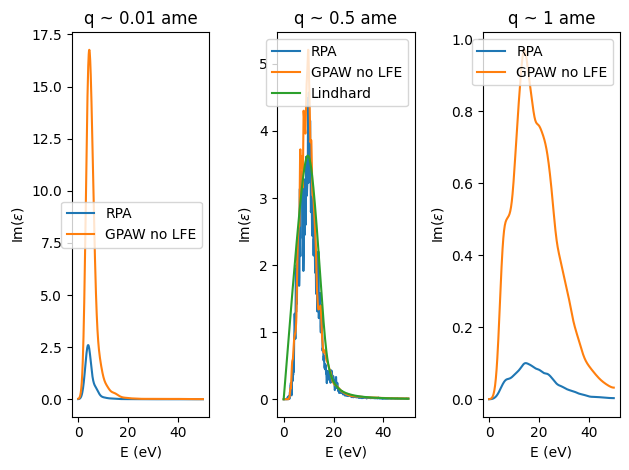

In [33]:
#Im plots
from scipy.ndimage import gaussian_filter1d

#Note factors multiplying RPA - where is this nonlinear factor coming from?

fig, ax = plt.subplots(1,3)
ax[0].plot(E, gaussian_filter1d(np.imag(eps[0,:]),10), label='RPA')
ax[0].plot(E, gaussian_filter1d(darkelf_gpaw.eps2(E, 0.01*alpha*mElectron),10), label='GPAW no LFE')
#ax[0].plot(E, np.imag(eps_l[0,:]), label='Lindhard')
ax[0].set_title('q ~ 0.01 ame')
ax[0].legend()

ax[1].plot(E, 8*np.imag(eps[25,:]), label='RPA')
ax[1].plot(E, darkelf_gpaw.eps2(E, 0.5*alpha*mElectron), label='GPAW no LFE')
ax[1].plot(E, np.imag(eps_l[25,:]), label='Lindhard')
ax[1].set_title('q ~ 0.5 ame')
ax[1].legend()

ax[2].plot(E, gaussian_filter1d(np.imag(eps[-1,:]),10), label='RPA')
ax[2].plot(E, gaussian_filter1d(darkelf_gpaw.eps2(E, 1*alpha*mElectron),10), label='GPAW no LFE')
#ax[2].plot(E, np.imag(eps_l[-1,:]), label='Lindhard')
ax[2].set_title('q ~ 1 ame')
ax[2].legend()

for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'Im($\epsilon)$')
plt.tight_layout()
plt.show()


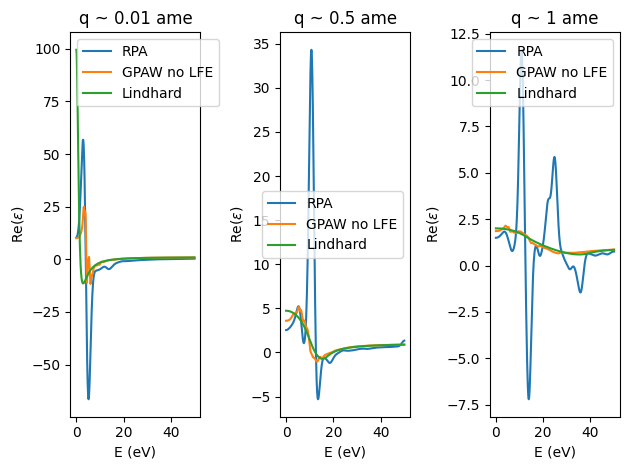

In [34]:
#Re plots

fig, ax = plt.subplots(1,3)
ax[0].plot(E, gaussian_filter1d(np.real(eps[0,:]),10), label='RPA')
ax[0].plot(E, darkelf_gpaw.eps1(E, 0.01*alpha*mElectron), label='GPAW no LFE')
ax[0].plot(E, np.real(eps_l[0,:]), label='Lindhard')
ax[0].set_title('q ~ 0.01 ame')
ax[0].legend()

ax[1].plot(E, gaussian_filter1d(np.real(eps[25,:]),10), label='RPA')
ax[1].plot(E, darkelf_gpaw.eps1(E, 0.5*alpha*mElectron), label='GPAW no LFE')
ax[1].plot(E, np.real(eps_l[25,:]), label='Lindhard')
ax[1].set_title('q ~ 0.5 ame')
ax[1].legend()

ax[2].plot(E, gaussian_filter1d(np.real(eps[-1,:]),10), label='RPA')
ax[2].plot(E, darkelf_gpaw.eps1(E, 1*alpha*mElectron), label='GPAW no LFE')
ax[2].plot(E, np.real(eps_l[-1,:]), label='Lindhard')
ax[2].set_title('q ~ 1 ame')
ax[2].legend()

for i in [0,1,2]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'Re($\epsilon)$')
plt.tight_layout()
plt.show()